In [1]:
import hvplot.xarray
import numpy as np
import xarray as xr

In [2]:
def load_merged_argo_dataset_and_tumo(time_smoothing, lat_bounds = None, suffix = None):
    ds_argo_merged = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/ds_argo_{time_smoothing}_viking{suffix}.nc')
    t_umo_obs = xr.open_dataset(f'../rapid-geostrophic-reconstruction/data/t_umo_sim_miss{suffix}.nc')
    t_umo_obs['time'] = t_umo_obs.time.dt.floor('D')
    t_umo_obs = t_umo_obs.resample(time = time_smoothing).mean()

    ds_argo_merged = ds_argo_merged.sel(time = t_umo_obs.time.data)#, method = 'nearest')
    ds_argo_merged = ds_argo_merged.isel(z = slice(None, None, -1))

    if lat_bounds is not None:
        ds_argo_merged = ds_argo_merged.where((ds_argo_merged.lat >= lat_bounds[0]) & (ds_argo_merged.lat <= lat_bounds[1]))

    return ds_argo_merged, t_umo_obs

In [3]:
# Load the argo_dataset and the ground truth dataset

import xarray as xr
import pandas as pd
time_smoothing = '90D'

lat_bounds = (25, 27)


# ds_argo_merged, t_umo_obs = load_merged_argo_dataset_and_tumo(time_smoothing)#, lat_bounds = lat_bounds)

def load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing):
    ds_argo_merged = None
    t_umo_obs = None
    assert len(suffixe) == 2, 'Longer? Think on the t_delta '

    for suffix in suffixe:
        ds_argo_merged_cycle, t_umo_obs_cycle = load_merged_argo_dataset_and_tumo(time_smoothing, suffix= suffix)

        if ds_argo_merged is None:
            ds_argo_merged = ds_argo_merged_cycle
            t_umo_obs = t_umo_obs_cycle
        else:
            t_delta = ds_argo_merged.time.max() - ds_argo_merged_cycle.time.min() + pd.Timedelta(time_smoothing)
            ds_argo_merged_cycle['time'] = ds_argo_merged_cycle['time'] + t_delta 
            t_umo_obs_cycle['time'] = t_umo_obs_cycle['time'] + t_delta
            ds_argo_merged_cycle['time_1d'] = ds_argo_merged_cycle['time_1d'] + t_delta

            ds_argo_merged = xr.concat([ds_argo_merged, ds_argo_merged_cycle], dim = 'time')
            t_umo_obs = xr.concat([t_umo_obs, t_umo_obs_cycle], dim = 'time')

    return ds_argo_merged, t_umo_obs, t_delta

suffixe = ['_70None', '_2nd_NoneNone']
ds_argo_merged, t_umo_obs, t_delta = load_merged_argo_dataset_and_tumo_cycles(suffixe, time_smoothing)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


## Single Profile Processing

We will load the ds_argo_merged dataset as thre base where each prfoile in the ten day window is present.
THen we will create 4 embedding one for each of the moorings and each profile is assigned by distance to those emebeddings. 
Each profile will create based on the currtent state and its rho values a delta that will be added to the embedding.

In [4]:
dv_dz_obs_1st = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_70None.nc')
dv_dz_obs_1st = dv_dz_obs_1st.resample(time = time_smoothing).mean()
dv_dz_obs_2nd = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_2nd_NoneNone.nc')
dv_dz_obs_2nd = dv_dz_obs_2nd.resample(time = time_smoothing).mean()

dv_dz_obs_2nd['time'] = dv_dz_obs_2nd['time'] + t_delta

dv_dz_obs = xr.concat([dv_dz_obs_1st, dv_dz_obs_2nd], dim = 'time')

dv_dz_obs.mean('time').dv_dz_times_X#.interpolate_na('z')

<xarray.DataArray 'dv_dz_times_X' (z: 242)>
array([-4.22443068e+00, -4.21170552e+00, -4.19896027e+00, -4.18619497e+00,
       -4.17340962e+00, -4.16060424e+00, -4.14777885e+00, -4.13493347e+00,
       -4.12206812e+00, -4.10918281e+00, -4.08863467e+00, -4.05972616e+00,
       -4.03097784e+00, -4.00238996e+00, -3.97396276e+00, -3.94569645e+00,
       -3.91759128e+00, -3.88964748e+00, -3.86186528e+00, -3.83424491e+00,
       -3.80678661e+00, -3.77949060e+00, -3.73930077e+00, -3.61436890e+00,
       -3.49033791e+00, -3.36720844e+00, -3.24498112e+00, -3.12365656e+00,
       -3.00323539e+00, -2.88371822e+00, -2.76510566e+00, -2.64739834e+00,
       -2.53059684e+00, -2.41470179e+00, -2.29971377e+00, -2.25224660e+00,
       -2.21665643e+00, -2.18135793e+00, -2.14635105e+00, -2.11163572e+00,
       -2.07721188e+00, -2.04307947e+00, -2.00923842e+00, -1.97568866e+00,
       -1.94243013e+00, -1.90946276e+00, -1.87678648e+00, -1.78949364e+00,
       -1.67303768e+00, -1.55740648e+00, -1.44260020e+00, -1.32861900e+00,
       -1.21546304e+00, -1.10313246e+00, -9.91627425e-01, -8.80948071e-01,
       -7.79175722e-01, -9.55901636e-02, -1.35648852e-01, -2.41910899e-01,
       -4.05047262e-01, -5.67328035e-01, -7.28753479e-01, -8.89323860e-01,
       -1.04903945e+00, -1.20790051e+00, -1.36590733e+00, -1.52306018e+00,
       -1.67935935e+00, -1.83480513e+00, -1.98939781e+00, -2.03174115e+00,
       -1.97846134e+00, -1.92558921e+00, -1.87312412e+00, -1.82106545e+00,
       -1.76941258e+00, -1.71816489e+00, -1.66732174e+00, -1.61688250e+00,
...
        2.69364892e+00,  2.86731437e+00,  3.03974590e+00,  3.21095350e+00,
        4.09594877e+00,  5.58668106e+00,  7.08808531e+00,  8.60017334e+00,
        1.01229572e+01,  1.16564493e+01,  1.32006621e+01,  1.47556084e+01,
        1.63213012e+01,  1.70706913e+01,  1.77152352e+01,  1.83605606e+01,
        1.90066776e+01,  1.96535964e+01,  2.03013270e+01,  2.09498795e+01,
        2.15992641e+01,  2.16362406e+01,  2.15627427e+01,  2.14903288e+01,
        2.14189915e+01,  2.13487235e+01,  2.12795176e+01,  2.12113665e+01,
        2.03527985e+01,  1.85565740e+01,  1.67409281e+01,  1.49058929e+01,
        1.30514997e+01,  1.11777788e+01,  9.28475967e+00,  5.76393674e+00,
        1.59513796e+00, -2.71529678e+00, -7.16627915e+00, -1.17567524e+01,
       -1.64856904e+01, -2.11127913e+01, -2.60489472e+01, -3.14143101e+01,
       -3.72035224e+01, -4.34114273e+01, -4.89884384e+01, -5.34613582e+01,
       -5.84840668e+01, -6.40492091e+01, -7.01497042e+01, -7.67610450e+01,
       -8.38826829e+01, -9.15150604e+01, -9.96520085e+01, -1.05383754e+02,
       -1.09566751e+02, -1.13898145e+02, -1.18085071e+02, -1.19905313e+02,
       -1.21720648e+02, -1.23502545e+02, -1.24997522e+02, -1.26438931e+02,
       -1.29068588e+02, -1.32688494e+02, -1.37705178e+02, -1.44923596e+02,
       -1.54865231e+02, -1.66985482e+02, -1.82266879e+02, -1.99369186e+02,
       -2.17029004e+02, -2.36606839e+02, -2.52466962e+02, -2.68315226e+02,
                   nan,             nan])
Coordinates:
  * z        (z) float64 -4.82e+03 -4.8e+03 -4.78e+03 ... -40.0 -20.0 -0.0

In [5]:
from copy import deepcopy

In [6]:
ds_argo_merged_10days, t_umo_10days, t_delta = load_merged_argo_dataset_and_tumo_cycles(['_70None', '_2nd_NoneNone'], '90D')

compartments = [
    ['west_p', -76.74, -70, 'west'],
    ['mar_west_p', -60, -47, 'east'],
    ['mar_east_p', -47, -40, 'west'],
    ['east_p', -30, -13.5, 'east']
]

# We only take the first 2000 meters depth
ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.z > -2000, drop = True)

ds_argo_merged_10days = ds_argo_merged_10days.where(ds_argo_merged_10days.salinity > 0).fillna(0)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) | (ds_argo_merged_10days.z > -100) , drop = True)
# ds_argo_merged_10days = ds_argo_merged_10days.where((ds_argo_merged_10days.z <= -1500) , drop = True)

/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(
/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/xarray/coding/times.py:254: RuntimeWarning: invalid value encountered in cast
  flat_num_dates_ns_int = (flat_num_dates * _NS_PER_TIME_DELTA[delta]).astype(


In [7]:
load_std = True

# Prepare a dataset by 1) splitting the data, 2) scaling the input data 
# train_slice_pos = 'start'

# train_ratio = .6
# val_ratio = .15


# t_umo_10days = t_umo_10days.sel(time = slice(None, '2020-01-01'))
# ds_argo_merged_10days = ds_argo_merged_10days.sel(time = slice(None, '2020-01-01'))


# indices = np.arange(t_umo_10days.time.shape[0])
# # np.random.shuffle(indices)


    


# if train_slice_pos == 'start':
#     train_indices = indices[:int(train_ratio * indices.shape[0])]
#     val_indices = indices[int(train_ratio * indices.shape[0]):int((train_ratio + val_ratio) * indices.shape[0])]
#     test_indices = indices[int((train_ratio + val_ratio) * indices.shape[0]):]
# elif train_slice_pos == 'end':
#     train_indices = indices[-int(train_ratio * indices.shape[0]):]
#     val_indices = indices[-int((train_ratio + val_ratio) * indices.shape[0]): -int(train_ratio * indices.shape[0])]
#     test_indices = indices[:-int((train_ratio + val_ratio) * indices.shape[0])]


test_indices = t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2005-01-01', '2025-01-01')).ti.values

valid_indices_1 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('1995-01-01', '2005-01-01')).ti.values
valid_indices_2 =  t_umo_10days.assign_coords(ti = ('time', np.arange(len(t_umo_10days.time)))).sel(time = slice('2025-01-01','2035-01-01')).ti.values

val_indices = np.concatenate([valid_indices_1, valid_indices_2])

train_mask = ~np.isin(np.arange(t_umo_10days.time.shape[0]), np.concatenate((val_indices, test_indices)))

train_indices = np.arange(t_umo_10days.time.shape[0])[train_mask]


rho_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).rho
temperature_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).temperature
salinity_mean = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).mean(['time', 'pos']).salinity

if load_std:
    temperature_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_temperature_std_argo.nc').temperature
    salinity_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_salinity_std_argo.nc').salinity
    rho_std = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho
    std_transport = xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_transport_std_argo.nc').dv_dz_times_X
else:
    rho_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).rho
    temperature_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).temperature
    salinity_std = ds_argo_merged_10days.where(ds_argo_merged_10days.profile_mask).isel(time = train_indices).std(['time', 'pos']).salinity
    std_transport = t_umo_10days.isel(time = train_indices).std('time').dv_dz_times_X




def standardize_rho(ds_pos, rho_mean=None, rho_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["rho"] = (ds_pos["rho"] - rho_mean) / rho_std
    return ds_pos

def standardize_temperature(ds_pos, temperature_mean=None, temperature_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["temperature"] = (ds_pos["temperature"] - temperature_mean) / temperature_std
    return ds_pos

def standardize_salinity(ds_pos, salinity_mean=None, salinity_std=None):
    ds_pos = deepcopy(ds_pos)
    ds_pos["salinity"] = (ds_pos["salinity"] - salinity_mean) / salinity_std
    return ds_pos


ds_argo_merged_10days_std = standardize_rho(
    ds_argo_merged_10days,
    rho_mean=rho_mean, 
    rho_std=rho_std,
)

ds_argo_merged_10days_std = standardize_temperature(
    ds_argo_merged_10days_std,
    temperature_mean=temperature_mean,
    temperature_std=temperature_std,
)

ds_argo_merged_10days_std = standardize_salinity(
    ds_argo_merged_10days_std,
    salinity_mean=salinity_mean,
    salinity_std=salinity_std,
)

ds_argo_merged_10days_std = ds_argo_merged_10days_std.fillna(0)

nn_feature_ds = xr.concat(
    [
        ds_argo_merged_10days_std.rho, 
        ds_argo_merged_10days_std.temperature, 
        ds_argo_merged_10days_std.salinity], dim = 'feature'
).stack(nn_feature = ['feature', 'z'])
train_X_scaled = nn_feature_ds.isel(time = train_indices).values
val_X_scaled = nn_feature_ds.isel(time = val_indices).values
test_X_scaled = nn_feature_ds.isel(time = test_indices).values


train_X_mask = ds_argo_merged_10days.isel(time = train_indices).profile_mask.fillna(0).astype(bool).values
val_X_mask = ds_argo_merged_10days.isel(time = val_indices).profile_mask.fillna(0).astype(bool).values
test_X_mask = ds_argo_merged_10days.isel(time = test_indices).profile_mask.fillna(0).astype(bool).values

train_X_lon = ds_argo_merged_10days.isel(time = train_indices).lon.values
val_X_lon = ds_argo_merged_10days.isel(time = val_indices).lon.values
test_X_lon = ds_argo_merged_10days.isel(time = test_indices).lon.values

offset_days = (
    (
        ds_argo_merged_10days.time_1d -
        ds_argo_merged_10days.time
    )
    .fillna(0).dt.days 
)

train_X_days = offset_days.isel(time = train_indices).values
val_X_days = offset_days.isel(time = val_indices).values
test_X_days = offset_days.isel(time = test_indices).values

train_y = t_umo_10days.isel(time = train_indices).dv_dz_times_X
val_y = t_umo_10days.isel(time = val_indices).dv_dz_times_X
test_y = t_umo_10days.isel(time = test_indices).dv_dz_times_X

mean_transport  = train_y.mean('time')

train_y_scaled = (train_y - mean_transport) / std_transport
val_y_scaled = (val_y - mean_transport) / std_transport
test_y_scaled = (test_y - mean_transport) / std_transport

train_y_scaled = train_y_scaled.fillna(0).values
val_y_scaled = val_y_scaled.fillna(0).values
test_y_scaled = test_y_scaled.fillna(0).values

# dv_dz_obs = xr.open_dataset('../rapid-geostrophic-reconstruction/data/dv_dz_sim_miss_70None.nc')
# dv_dz_obs = dv_dz_obs.resample(time = time_smoothing).mean()
dv_dz_moorings = dv_dz_obs.sel(time = ds_argo_merged_10days.time).where(dv_dz_obs.z <= -2000, drop = True)

mean_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).mean(['time']).dv_dz_times_X
std_dv_dz_moorings = dv_dz_moorings.isel(time = train_indices).std(['time']).dv_dz_times_X

train_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = train_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
val_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = val_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values
test_dv_dz_moorings_scaled = ((dv_dz_moorings.isel(time = test_indices).dv_dz_times_X - mean_dv_dz_moorings) / std_dv_dz_moorings).fillna(0).values



ds_argo_merged_10days


<xarray.Dataset>
Dimensions:       (time: 485, pos: 671, z: 29)
Coordinates:
  * time          (time) datetime64[ns] 1970-04-01 1970-06-30 ... 2089-07-05
  * pos           (pos) int64 0 1 2 3 4 5 6 7 ... 664 665 666 667 668 669 670
  * z             (z) float32 -3.047 -9.454 -16.36 ... -1.655e+03 -1.85e+03
    pressure      (z) float32 3.047 9.454 16.36 ... 1.471e+03 1.655e+03 1.85e+03
    lon           (time, pos) float32 -34.6 -68.3 -62.8 -16.55 ... nan nan nan
    lat           (time, pos) float32 25.88 27.11 28.08 28.72 ... nan nan nan
    time_1d       (time, pos) datetime64[ns] 1970-02-16T12:00:00 ... NaT
Data variables:
    temperature   (time, pos, z) float32 21.32 21.32 21.32 21.32 ... 0.0 0.0 0.0
    salinity      (time, pos, z) float32 37.03 37.03 37.03 37.03 ... 0.0 0.0 0.0
    profile_mask  (time, pos, z) float64 1.0 1.0 1.0 1.0 1.0 ... 0.0 0.0 0.0 0.0
    ct            (time, pos, z) float64 21.25 21.25 21.25 21.25 ... 0.0 0.0 0.0
    rho           (time, pos, z) float64 1.026e+03 1.026e+03 ... 0.0 0.0

In [8]:
train_X_days

array([[-44, -44, -39, ...,   0,   0,   0],
       [-45, -45, -41, ...,   0,   0,   0],
       [-45, -45, -45, ...,   0,   0,   0],
       ...,
       [-45, -41, -38, ...,   0,   0,   0],
       [-45, -45, -45, ...,   0,   0,   0],
       [-45, -45, -39, ...,   0,   0,   0]])

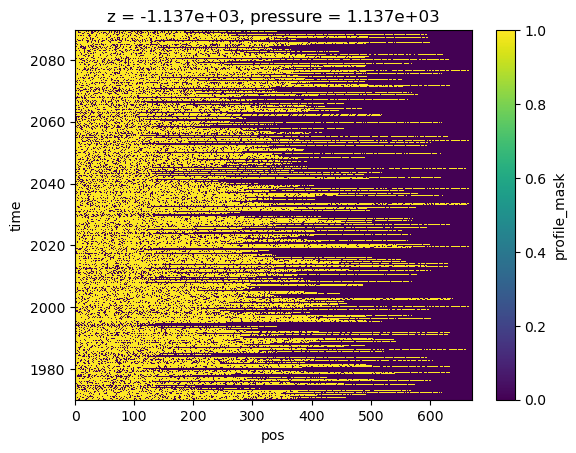

In [9]:
ds_argo_merged_10days.profile_mask.isel(z = -5).plot()

In [10]:
ds_argo_merged_10days.where((ds_argo_merged_10days.profile_mask)).isel(time = train_indices).rho.isel(z = -2).hvplot.kde()

:NdOverlay   [Variable]
   :Distribution   [value]   (Density)

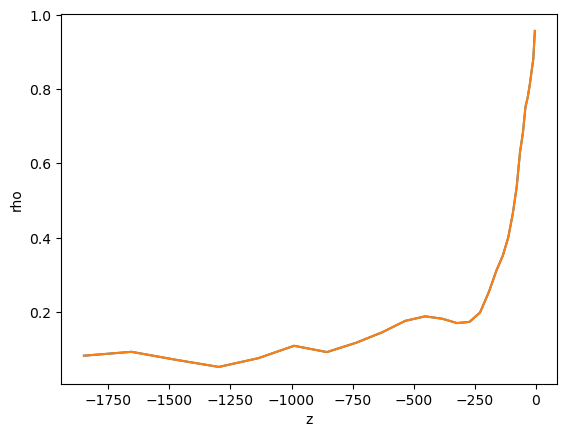

In [11]:
xr.open_dataset('../rapid-geostrophic-reconstruction/data/train_rho_std_argo.nc').rho.plot()
rho_std.plot()

In [12]:
from torch.utils.data import DataLoader, TensorDataset, Dataset
class ProfileDataset(Dataset):
    def __init__(self, X, y, mask, lon, dv_dz, days, compartments):
        self.X = X
        self.y = y
        self.mask = mask
        self.lon = lon
        self.days = days
        self.compartment = compartments 
        self.dv_dz = dv_dz

        self.len_compartments = len(compartments)

        self.X_per_compartment = []
        self.lon_per_compartment = []
        self.dv_dz_per_compartment = []
        self.days_per_compartment = []

        self.min_longitude = min([comp[1] for comp in compartments])
        self.max_longitude = max([comp[2] for comp in compartments])



        self.lon_scaled = (self.lon - self.min_longitude) / (self.max_longitude - self.min_longitude)

        self.days_scaled = self.days / (pd.Timedelta(time_smoothing).days / 2)
        
        for i in range(len(self)):
            mask = self.mask[i]


            compartment_X_per_sample = []
            compartment_lon_per_sample = []
            compartment_days_per_sample = []

            for j in range(self.len_compartments):

                # get all profile indices that are in the compartment and in the mask 
                profile_indices = np.where((self.lon[i] > self.compartment[j][1]) & (self.lon[i] < self.compartment[j][2]) & mask.any(axis = -1))[0]

                if len(profile_indices) < 1:
                    compartment_X_per_sample.append(np.empty(0))
                    compartment_lon_per_sample.append(np.empty(0))
                    compartment_days_per_sample.append(np.empty(0))
                    continue

                lon_compartments = self.lon_scaled[i][profile_indices]
                sorted_indices_longitude = lon_compartments.argsort()


                # If I have the sequence -5, -15, 5 the argsort will return [1, 0, 2]
                # As we want to have those profiles as last that are closes to the mooring due to the vanishing gradient 
                # For West moorings the smallest value has to be the last one
                if self.compartment[j][3] == 'west':
                    sorted_indices_longitude = sorted_indices_longitude[::-1]
                
                profile_indices = profile_indices[sorted_indices_longitude]

                compartment_X_per_sample.append(self.X[i][ profile_indices])
                compartment_lon_per_sample.append(self.lon_scaled[i][profile_indices])
                compartment_days_per_sample.append(self.days_scaled[i][profile_indices])
            

            self.X_per_compartment.append(compartment_X_per_sample)
            self.lon_per_compartment.append(compartment_lon_per_sample)
            self.dv_dz_per_compartment.append(self.dv_dz[i])
            self.days_per_compartment.append(compartment_days_per_sample)


    def __len__(self):
        return self.X.shape[0] 

    def __getitem__(self, idx):
        return self.X_per_compartment[idx], self.y[idx], self.lon_per_compartment[idx], self.dv_dz_per_compartment[idx], self.days_per_compartment[idx]

In [14]:
import torch
train_dataset = ProfileDataset(train_X_scaled, train_y, train_X_mask, train_X_lon, train_dv_dz_moorings_scaled, train_X_days, compartments)
val_dataset = ProfileDataset(val_X_scaled, val_y, val_X_mask, val_X_lon, val_dv_dz_moorings_scaled, val_X_days, compartments)
test_dataset = ProfileDataset(test_X_scaled, test_y, test_X_mask, test_X_lon, test_dv_dz_moorings_scaled, test_X_days, compartments)
    

def merge_profiles(data):
    """
        X: is a list and each entry is a list of compartments in which the profiles are stored with variable length
    """
    X, y, lon, dv_dz, days = zip(*data)
    X = [[torch.tensor(x_compartment).float() for x_compartment in x_sample] for x_sample in X]
    y = torch.tensor(np.array(y)).float()
    lon = [[torch.tensor(lon_compartment).float() for lon_compartment in lon_sample] for lon_sample in lon]
    dv_dz = [torch.tensor(dv_dz_sample).float() for dv_dz_sample in dv_dz]
    days = [[torch.tensor(days_compartment).float() for days_compartment in day_sample] for day_sample in days]

    return X, y, lon, dv_dz, days

dl = DataLoader(train_dataset, batch_size=4, shuffle=True, collate_fn=merge_profiles)
val_dl = DataLoader(val_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)


In [15]:
from torch import nn

class PredictionToTransportModel(nn.Module):

    def __init__(self, z_scale, mean_per_z, std_per_z ):
        super(PredictionToTransportModel, self).__init__()
        self.mean_per_z = torch.tensor(mean_per_z).float()
        self.std_per_z = torch.tensor(std_per_z).float()
        self.bottom_index = np.argmin(np.abs(z_scale - -4800).values)
        self.amoc_index = np.argmin(np.abs(z_scale - -1000).values)

    def forward(self, x):
        x = x * self.std_per_z + self.mean_per_z

        dv_dz_prediction = x

        return (
            -((torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20) -
            (torch.cumsum(dv_dz_prediction.flip(-1), -1) * 20).flip(-1)[:, [self.bottom_index]]).cumsum(-1) * 20 / 1e6
        ).flip(-1)[:, self.amoc_index]


class CompartmentModel(nn.Module):

    def __init__(self, n_features, n_embedding):
        super(CompartmentModel, self).__init__()
        self.n_features = n_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_features + n_embedding + 1 + 1, 256)
        self.fc2 = nn.Linear(256, 128)
        self.dropout1 = nn.Dropout(p=.015)
        self.fc3 = nn.Linear(128, n_embedding)
        self.dropout2 = nn.Dropout(p=.15)
        self.fc4 = nn.Linear(n_embedding, n_embedding)

    def forward(self, x):
        x = torch.relu(self.fc1(x))
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.fc4(x)
        return x

class ProfileModel(nn.Module):
    def __init__(self, n_features, n_compartments, n_embedding, n_dvdz_features, z_scale):
        super(ProfileModel, self).__init__()
        self.n_compartments = n_compartments
        self.n_features = n_features
        self.n_dvdz_features = n_dvdz_features
        self.n_embedding = n_embedding
        self.fc1 = nn.Linear(n_embedding * n_compartments +n_dvdz_features  , 256)
        self.bn1 = nn.BatchNorm1d(num_features=256)
        self.fc2 = nn.Linear(256,128)
        self.dropout1 = nn.Dropout(p=.25)
        self.fc3 = nn.Linear(128,64)
        self.dropout2 = nn.Dropout(p=.33)
        self.fc4 = nn.Linear(64,64)
        self.bn2 = nn.BatchNorm1d(num_features=64)
        self.dropout3 = nn.Dropout(p=.2)
        self.fc5 = nn.Linear(64,32)
        self.fc6 = nn.Linear(32,242)

        self.compartment_models = nn.ModuleList([CompartmentModel(n_features, n_embedding) for _ in range(n_compartments)])
        self.transformer = PredictionToTransportModel(z_scale, dv_dz_obs.dv_dz_times_X.mean('time').fillna(0).values, dv_dz_obs.dv_dz_times_X.std('time').fillna(1).values)

        self.lstms = nn.ModuleList([nn.LSTM(n_features + 2, n_embedding, batch_first = True, dropout = .25) for _ in range(n_compartments)])

    def forward(self, x, lon, dv_dz, days):

        
        batch_embeddings = []
        for batch_i in range(len(x)):
            compartment_embeddings = []
            x_batch = x[batch_i]
            for i in range(self.n_compartments):
                x_compartment = x_batch[i]


                if len(x_compartment) < 1:
                    compartment_embeddings.append(torch.zeros(self.n_embedding).float())
                else:
                    input_to_layer = torch.cat((x_compartment, lon[batch_i][i].reshape(-1,1), days[batch_i][i].reshape(-1,1)), dim = -1)
                    output, (hn, cn) = self.lstms[i](input_to_layer)
                    compartment_embeddings.append(hn.squeeze(0))
                continue


                compartment_embedding = torch.zeros(self.n_embedding).float()
                compartment_embeddings_for_mean = []
                for x_profile, lon_profile, day_profile in zip(x_compartment, lon[batch_i][i], days[batch_i][i]):
                    
                    input_to_compartment_embedding = torch.cat([x_profile, compartment_embedding, lon_profile.unsqueeze(0), day_profile.unsqueeze(0)]).float()
                    

                    
                    compartment_embedding = compartment_embedding + self.compartment_models[i](input_to_compartment_embedding).float()
                #     compartment_embeddings_for_mean.append(self.compartment_models[i](input_to_compartment_embedding).float())
                
                # if len(compartment_embeddings_for_mean) < 1:
                #     compartment_embedding = torch.zeros(self.n_embedding).float()
                # else:
                #     compartment_embedding = torch.stack(compartment_embeddings_for_mean).mean(dim = 0)    
                # if len(x_compartment) > 0:
                #     compartment_embedding /= len(x_compartment)

                    compartment_embedding = torch.tanh(compartment_embedding)

                # compartment_embedding_norm = torch.norm(compartment_embedding, dim = -1, keepdim = True)
                # compartment_embedding = compartment_embedding / (compartment_embedding_norm + 1e-6)


                compartment_embeddings.append(compartment_embedding)

            embedding_all_profiles = torch.concat(compartment_embeddings +[dv_dz[batch_i]], dim = 0)
            batch_embeddings.append(embedding_all_profiles)
        embedding_all_profiles = torch.stack(batch_embeddings)
        assert not torch.isnan(embedding_all_profiles).any(), 'NaN in embedding_all_profiles'
        x = torch.relu(self.fc1(embedding_all_profiles))
        # x = self.bn1(x)
        # x = self.dropout1(x)
        x = torch.relu(self.fc2(x))
        x = self.dropout2(x)
        x = torch.relu(self.fc3(x))
        x = self.dropout3(x)
        x = torch.relu(self.fc4(x))
        # x = self.bn2(x)
        x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        x = x.squeeze(dim = -1)

        return self.transformer(x)
        



In [16]:
model = ProfileModel(train_X_scaled.shape[2], len(compartments), 64, train_dv_dz_moorings_scaled.shape[1], ds_argo_merged_10days.z)
model.float()
for X, y, lon, dvdz, days in dl:
    print(model(X, lon, dvdz, days).squeeze(), y)
    break

tensor([-25.5037, -25.5085, -25.5021, -25.4991], grad_fn=<SqueezeBackward0>) tensor([-12.9474, -29.6288, -20.2017, -16.9712])


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/torch/nn/modules/rnn.py:82: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


In [17]:
train_X_scaled.shape[2]

87

In [63]:
from torch import optim

torch.random.manual_seed(42)
np.random.seed(42)


model = ProfileModel(train_X_scaled.shape[2], len(compartments), 64 * 4, train_dv_dz_moorings_scaled.shape[1] , ds_argo_merged_10days.z)
model.float()
criterion = nn.MSELoss()
# criterion = nn.L1Loss()
# optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-4)
optimizer = optim.SGD(model.parameters(), lr=0.0001, weight_decay=1e-5, momentum=.9)
num_epochs = 100
lr_scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=num_epochs)

best_val_loss = 1e10
best_model = None
best_epoch = 0

for epoch in range(num_epochs):  # loop over the dataset multiple times

    model.train()
    loss_per_epoch = 0.0
    for i, data in enumerate(dl, 0):
        # get the inputs; data is a list of [inputs, labels]
        X, y, lon, dvdz, days = data
        

        # zero the parameter gradients
        optimizer.zero_grad()

        # forward + backward + optimize
        outputs = model(X, lon, dvdz, days)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()

        # print statistics
        loss_per_epoch += loss.item()

    lr_scheduler.step()

    model.eval()
    total_val_loss = 0.
    for X, y, lon, dvdz, days in val_dl:
        val_prediction = model(X, lon, dvdz, days).detach()
        val_loss = criterion(val_prediction, y).item()

        total_val_loss += val_loss

    total_val_loss /= len(val_dl)
    if total_val_loss < best_val_loss:
        best_val_loss = total_val_loss
        best_epoch = epoch
        best_model = deepcopy(model)
        print('New best model found in epoch: ', epoch, 'with val loss: ', total_val_loss)

    if (epoch+1) % 3 == 0:
        print(f'Epoch {epoch}, Loss: {loss_per_epoch / len(dl)}, Val loss: {total_val_loss}')

    if epoch - best_epoch > 20:
        break


/gxfs_home/geomar/smomw507/.conda/envs/amoc_recons/lib/python3.9/site-packages/torch/nn/modules/rnn.py:82: UserWarning: dropout option adds dropout after all but last recurrent layer, so non-zero dropout expects num_layers greater than 1, but got dropout=0.25 and num_layers=1
  warnings.warn("dropout option adds dropout after all but last "


New best model found in epoch:  0 with val loss:  43.91406377156576
New best model found in epoch:  1 with val loss:  24.763853073120117
New best model found in epoch:  2 with val loss:  19.10870424906413
Epoch 2, Loss: 17.756595608628828, Val loss: 19.10870424906413
New best model found in epoch:  3 with val loss:  17.44049326578776
New best model found in epoch:  4 with val loss:  15.154682795206705
New best model found in epoch:  5 with val loss:  14.835014661153158
Epoch 5, Loss: 11.435640310063775, Val loss: 14.835014661153158
New best model found in epoch:  6 with val loss:  14.400361061096191
New best model found in epoch:  7 with val loss:  13.313332875569662
New best model found in epoch:  8 with val loss:  12.117163022359213
Epoch 8, Loss: 8.286980328920446, Val loss: 12.117163022359213
Epoch 11, Loss: 6.799775624716723, Val loss: 15.561662356058756
New best model found in epoch:  14 with val loss:  10.865601857503256
Epoch 14, Loss: 5.146776989654258, Val loss: 10.8656018575

In [64]:
test_dl = DataLoader(test_dataset, batch_size=32, shuffle=False, collate_fn=merge_profiles)

test_predictions = []

model = best_model
model.eval()
total_test_loss = 0.

for X, y, lon, dvdz, days in test_dl:

    test_prediction = model(X, lon, dvdz, days).detach()
    test_loss = criterion(test_prediction, y).item()

    total_test_loss += test_loss
    test_predictions.append(test_prediction)

test_predictions = torch.cat(test_predictions)

# test_predictions = (test_predictions * std_transport) + mean_tranport

In [65]:
argo_numbers_per_compartment = np.empty((len(test_dataset), len(compartments)))

for i, (x, _, _, _, _) in enumerate(test_dataset):
    for j, x_compartment in enumerate(x):
        argo_numbers_per_compartment[i, j] = len(x_compartment)


argo_numbers_per_compartment = xr.DataArray(
    argo_numbers_per_compartment,
    coords = {
        'time': t_umo_10days.time.isel(time = test_indices)
    },
    dims = ['time', 'compartment'],
    name = 'argo_numbers_per_compartment'
)

### Results

In [66]:


transport = xr.DataArray(
    test_predictions,
    coords={
        'time':ds_argo_merged_10days_std.isel(time = test_indices).time
    }, name='dv_dz_times_X')
(
    (   
    transport.hvplot(label = 'NN')
        * t_umo_obs.sel(time = transport.time, method = 'nearest').hvplot(label = 'rapid')
        # * t_merged_argo_2000.sel(time = transport.time, method = 'nearest').hvplot(label = 'argo')
) +

(
    argo_numbers_per_compartment.isel(compartment = 0).hvplot(label = compartments[0][0]) *
    argo_numbers_per_compartment.isel(compartment = 1).hvplot(label = compartments[1][0]) *
    argo_numbers_per_compartment.isel(compartment = 2).hvplot(label = compartments[2][0]) *
    argo_numbers_per_compartment.isel(compartment = 3).hvplot(label = compartments[3][0])
)


).cols(1)

:Layout
   .Overlay.I  :Overlay
      .Curve.NN    :Curve   [time]   (dv_dz_times_X)
      .Curve.Rapid :Curve   [time]   (dv_dz_times_X)
   .Overlay.II :Overlay
      .Curve.West_p     :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_west_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.Mar_east_p :Curve   [time]   (argo_numbers_per_compartment)
      .Curve.East_p     :Curve   [time]   (argo_numbers_per_compartment)

In [67]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
const_prediction_MAE = np.abs(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X - t_umo_obs.sel(time = ds_argo_merged_10days_std.isel(time = train_indices).time, method = "nearest").dv_dz_times_X.mean()).mean().values

mae_error = mean_absolute_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)

print(f'R2: {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')
print(f'MAE: {mae_error}; const MAE {const_prediction_MAE}', f' improvement percentage:  {(const_prediction_MAE - mae_error) / const_prediction_MAE * 100:.2f}%')
print(f'MSE: {mean_squared_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)}')

R2: 0.5215392988870657
MAE: 1.9880781723669585; const MAE 3.2931010641811223  improvement percentage:  39.63%
MSE: 7.52071550527305


In [68]:
print(f'R2 {r2_score(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)*100:.2f}%; MAE {mae_error:.2f}; MSE {mean_squared_error(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values):.2f}')

R2 52.15%; MAE 1.99; MSE 7.52


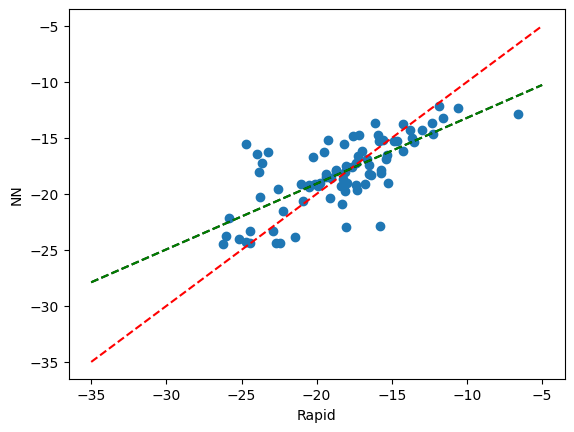

In [69]:
import matplotlib.pyplot as plt
plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, transport.values)
# plt.scatter(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values, t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values)
plt.xlabel('Rapid')
plt.ylabel('NN')
plt.plot([-35, -5], [-35, -5], 'r--')

from sklearn.linear_model import LinearRegression

lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), transport.values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'k--')
# lr = LinearRegression().fit(t_umo_obs.sel(time = transport.time, method = "nearest").dv_dz_times_X.values.reshape(-1, 1), t_merged_argo_2000.sel(time = transport.time, method = 'nearest').values.reshape(-1, 1))
in_X = np.linspace(-35, -5, 100).reshape(-1, 1)
plt.plot(in_X, lr.predict(in_X), 'g--')

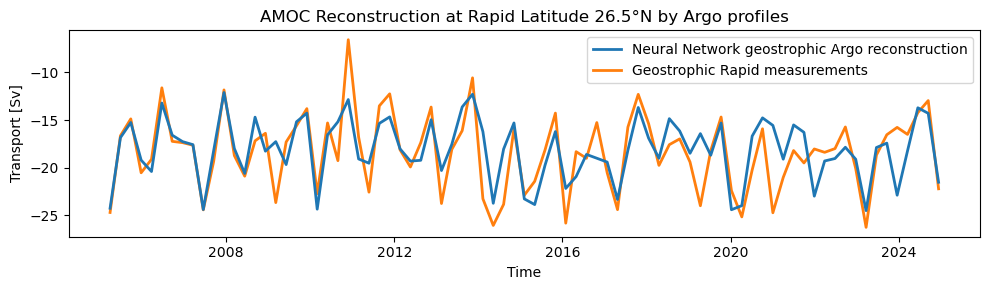

In [70]:
fig = plt.figure(figsize=(10, 3))
ax = fig.add_subplot(1,1,1)

# calc = t_merged_argo_2000.sel(time = transport.time, method = 'nearest')
# ax.plot(calc.time, calc.values, label = 'Geostrohphic calculation from Argos', alpha = .5, color = 'black')
rapid = t_umo_obs.sel(time = transport.time, method = 'nearest')
ax.plot(transport.time, transport.values, label = 'Neural Network geostrophic Argo reconstruction', linewidth = 2, zorder = 20)
ax.plot(rapid.time, rapid.dv_dz_times_X.values, label = 'Geostrophic Rapid measurements', linewidth = 2)

plt.legend()
ax.set_ylabel('Transport [Sv]')
ax.set_xlabel('Time')
plt.title('AMOC Reconstruction at Rapid Latitude 26.5°N by Argo profiles')
fig.tight_layout()
plt.savefig('argo_nn_reconstruction.png')





#### From top to bottom 
-   20meter R2 0.37%; MAE 2.19; MSE 7.55
-  100meter R2 0.38%; MAE 2.21; MSE 7.47
-  200meter R2 0.46%; MAE 2.00; MSE 6.47
-  400meter R2 0.22%; MAE 2.40; MSE 9.42
-  500meter R2 0.20%; MAE 2.53; MSE 9.68
-  750meter R2 0.38%; MAE 2.15; MSE 7.47
- 1000meter R2 0.37%; MAE 2.15; MSE 7.52
- 1500meter R2 0.28%; MAE 2.38; MSE 8.65
- 2000meter R2 0.54%; MAE 1.77; MSE 5.48


#### From bottom to top
-   20meter R2 0.28%; MAE 2.31; MSE 8.67
-  200meter R2 0.27%; MAE 2.34; MSE 8.82
-  500meter R2 0.20%; MAE 2.49; MSE 9.66
- 1000meter R2 0.21%; MAE 2.48; MSE 9.56
- 1500meter R2 0.18%; MAE 2.57; MSE 9.87


#### Inbetween 
- 0-20 and 1500-2000 R2 0.48%; MAE 1.92; MSE 6.25
- 0-100 and 1500-200 R2 0.55%; MAE 1.86; MSE 5.36


### Transfer this to a RPAID dataset 

In [54]:
torch.save(best_model.state_dict(), '../rapid-geostrophic-reconstruction/data/11_viking_gesotrophic_prediction_multiple_cycles.pt')